# Exploración de `tags`

## 1. Introducción

Este notebook explora la tabla de etiquetas libres (`tags.csv`) de forma aislada, sin combinarla
todavía con `movies` ni `ratings`. El objetivo es caracterizar el etiquetado en sí mismo:

* ¿Cuántas etiquetas hay, sobre cuántas películas y puestas por cuántos usuarios?
* ¿Cómo ha evolucionado la actividad de etiquetado en el tiempo?
* ¿Qué palabras usa la gente con más frecuencia para etiquetar películas?
* ¿Qué tan concentrada está la actividad de etiquetado — todos los usuarios etiquetan por igual, o
  hay unos pocos que dominan?

**Aviso sobre el origen de los datos:** `tags.csv` es la **tabla completa y real**, sin muestreo —
todas las cifras de este notebook corresponden al dataset completo, no a una estimación.

## 2. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 3. Carga de datos

In [2]:
RUTA_TAGS = '../../../data/processed/tags.csv'

tags = pd.read_csv(RUTA_TAGS)

print(f"tags: {tags.shape[0]:,} filas (tabla completa, sin muestreo)")

tags: 1,992,636 filas (tabla completa, sin muestreo)


## 4. Exploración inicial de `tags`

**Qué se calcula:** dimensiones, tipos de dato por columna, nulos, filas totalmente duplicadas y
duplicados de `(userId, movieId, tag)`.

**Por qué es necesario:** antes de calcular cualquier estadística hay que confirmar el tamaño real de
la tabla y detectar problemas de calidad (nulos, duplicados) que deban tratarse antes de seguir.

In [3]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 1992636 entries, 0 to 1992635
Data columns (total 4 columns):
 #   Column        Dtype
---  ------        -----
 0   userId        int64
 1   movieId       int64
 2   tag           str  
 3   tag_datetime  str  
dtypes: int64(2), str(2)
memory usage: 60.8 MB


In [4]:
print("Valores nulos por columna:")
print(tags.isnull().sum())
print()
print("Filas totalmente duplicadas:", tags.duplicated().sum())
print("Duplicados de (userId, movieId, tag):", tags.duplicated(subset=['userId', 'movieId', 'tag']).sum())
print()
print("Usuarios únicos:", tags['userId'].nunique())
print("Películas etiquetadas (movieId únicos):", tags['movieId'].nunique())

Valores nulos por columna:
userId          0
movieId         0
tag             6
tag_datetime    0
dtype: int64



Filas totalmente duplicadas: 0


Duplicados de (userId, movieId, tag): 0

Usuarios únicos: 15834
Películas etiquetadas (movieId únicos): 51069


**Resultados:** la tabla tiene 1,992,636 filas, con solo 6 valores nulos en `tag` (menos del
0.001% del total) y ninguna fila duplicada, ni exacta ni por `(userId, movieId, tag)`. Hay 15,834
usuarios únicos que han etiquetado, y 51,069 películas con al menos una etiqueta (de las 86,967 del
catálogo completo).

**Conclusión:** la tabla está prácticamente limpia — el único ajuste necesario es eliminar los 6
registros con `tag` nulo, ya que no aportan información. Solo el 59% del catálogo (51,069 de 86,967
películas) tiene al menos una etiqueta; el resto nunca fue comentado por ningún usuario.

### Unidad de observación

Cada fila de `tags` representa **un evento de etiquetado**: un usuario le puso una palabra o frase
libre a una película en un momento determinado (`tag_datetime`). Un mismo usuario puede etiquetar la
misma película varias veces con tags distintos (o incluso el mismo tag escrito con diferente
mayúscula/espaciado, al ser texto libre y no una categoría cerrada como el género), así que un evento
de etiquetado no equivale a "una opinión por película" — puede haber muchos eventos sobre la misma
película.

## 5. Transformaciones

**Qué se hace:** se eliminan las filas con `tag` nulo, se normaliza el texto del tag (minúsculas,
sin espacios sobrantes al inicio/final) en una columna nueva `tag_norm`, y se extrae el año
(`anio`) desde `tag_datetime`.

**Por qué es necesaria:** sin normalizar, "Sci-Fi", "sci-fi " y "SCI-FI" se contarían como tres
etiquetas distintas cuando en realidad son la misma, subestimando la frecuencia real de cada tag y
sobreestimando cuántas etiquetas distintas tiene una película. Extraer el año permite analizar la
evolución temporal del etiquetado.

In [5]:
tags_limpio = tags.dropna(subset=['tag']).copy()
tags_limpio['tag_norm'] = tags_limpio['tag'].str.strip().str.lower()
tags_limpio['tag_datetime'] = pd.to_datetime(tags_limpio['tag_datetime'])
tags_limpio['anio'] = tags_limpio['tag_datetime'].dt.year

print(f"Filas después de quitar nulos: {len(tags_limpio):,} (se eliminaron {len(tags) - len(tags_limpio)})")
print(f"Tags únicos sin normalizar: {tags_limpio['tag'].nunique():,}")
print(f"Tags únicos normalizados:   {tags_limpio['tag_norm'].nunique():,}")

Filas después de quitar nulos: 1,992,630 (se eliminaron 6)
Tags únicos sin normalizar: 140,191


Tags únicos normalizados:   131,350


**Resultados:** al normalizar, los tags únicos bajan de 140,191 a 131,350 — casi 9,000 variantes
de mayúsculas/espacios se fusionaron con su forma "real".

**Conclusión:** la normalización sí tiene un efecto medible y confirma que es un paso necesario antes
de contar frecuencias de tags. Sigue siendo una normalización básica: no corrige errores de tipeo ni
sinónimos (por ejemplo, "sci-fi" y "science fiction" siguen contando como tags distintos), así que la
cantidad real de conceptos únicos es probablemente menor a 131,350.

## 6. Exploración descriptiva de `tags`

### 6.1 Cobertura general

**Qué se calcula:** número total de eventos de etiquetado, usuarios, películas etiquetadas y
tags distintos (normalizados).

In [6]:
print(f"Total de eventos de etiquetado: {len(tags_limpio):,}")
print(f"Usuarios que han etiquetado: {tags_limpio['userId'].nunique():,}")
print(f"Películas con al menos un tag: {tags_limpio['movieId'].nunique():,} de 86,967 del catálogo")
print(f"Tags distintos (normalizados): {tags_limpio['tag_norm'].nunique():,}")

Total de eventos de etiquetado: 1,992,630
Usuarios que han etiquetado: 15,833
Películas con al menos un tag: 51,069 de 86,967 del catálogo
Tags distintos (normalizados): 131,350


**Resultados:** 1,992,630 eventos de etiquetado, de 15,833 usuarios, sobre 51,069 películas
(58.7% del catálogo), con 131,350 tags distintos.

**Conclusión:** el etiquetado cubre una minoría de usuarios (mucho menos que los 200,948 que califican
en `ratings`) pero un vocabulario enorme y variado — en promedio hay más de 15 eventos de etiquetado
por cada tag distinto, lo que sugiere que unos pocos tags son muy populares y la mayoría se usa muy
poco (se confirma en 6.3).

### 6.2 Distribución temporal

**Qué se calcula:** cantidad de eventos de etiquetado por año.

**Por qué es relevante:** permite ver si la actividad de etiquetado creció, se mantuvo estable o tuvo
picos concentrados en ciertos años.

In [7]:
por_anio = tags_limpio['anio'].value_counts().sort_index()
print(por_anio.describe())
print()
print(por_anio.to_dict())

count        19.000000
mean     104875.263158
std      134862.650053
min          27.000000
25%       38108.000000
50%       58307.000000
75%       90856.000000
max      572285.000000
Name: count, dtype: float64



{2005: 27, 2006: 28624, 2007: 25054, 2008: 16414, 2009: 58307, 2010: 46194, 2011: 48422, 2012: 41255, 2013: 48440, 2014: 34961, 2015: 91248, 2016: 83056, 2017: 83373, 2018: 311109, 2019: 90464, 2020: 153804, 2021: 572285, 2022: 198669, 2023: 60924}


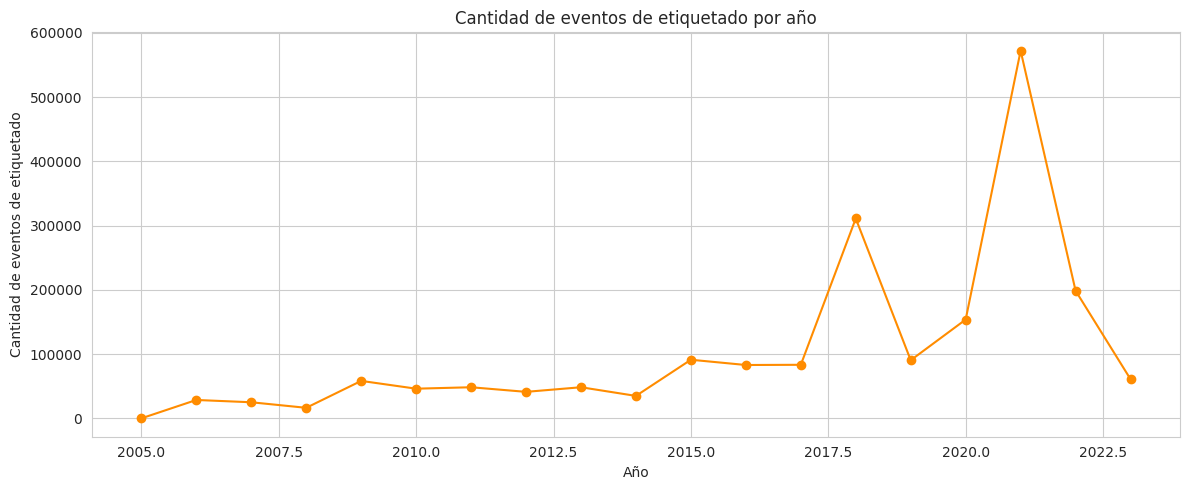

In [8]:
plt.figure(figsize=(12, 5))
por_anio.plot(kind='line', marker='o', color='darkorange')
plt.xlabel('Año')
plt.ylabel('Cantidad de eventos de etiquetado')
plt.title('Cantidad de eventos de etiquetado por año')
plt.tight_layout()
plt.show()

**Resultados:** el etiquetado va desde 2005 (apenas 27 eventos, arranque de la función) hasta
2023, con una tendencia general al alza. Hay tres picos muy marcados: 2018 (311,109), 2021 (572,285, el
año con más actividad por lejos) y en menor medida 2020 (153,804) y 2022 (198,669).

**Conclusión:** a diferencia de `ratings` (que mostraba oleadas moderadas), aquí hay picos
extremadamente pronunciados, sobre todo en 2021. Esto es sospechoso de no ser actividad orgánica de
miles de usuarios distintos, sino de unos pocos usuarios muy activos concentrando su actividad en
periodos cortos — hipótesis que se confirma en la sección 6.6.

### 6.3 Tags más frecuentes

**Qué se calcula:** frecuencia de los 20 tags normalizados más usados.

**Por qué es relevante:** permite ver qué tipo de información aporta el etiquetado libre: ¿son
géneros escritos con otras palabras, nombres de actores, opiniones de calidad, temas?

In [9]:
top_tags = tags_limpio['tag_norm'].value_counts().head(20)
top_tags

tag_norm
sci-fi                11433
atmospheric           10062
action                 9302
comedy                 9270
funny                  8085
surreal                7452
visually appealing     7149
based on a book        6697
twist ending           6599
romance                6193
dark comedy            6150
thought-provoking      5999
dystopia               5661
violence               5471
cinematography         5328
murder                 5222
social commentary      5192
fantasy                5143
thriller               5035
stylized               4947
Name: count, dtype: int64

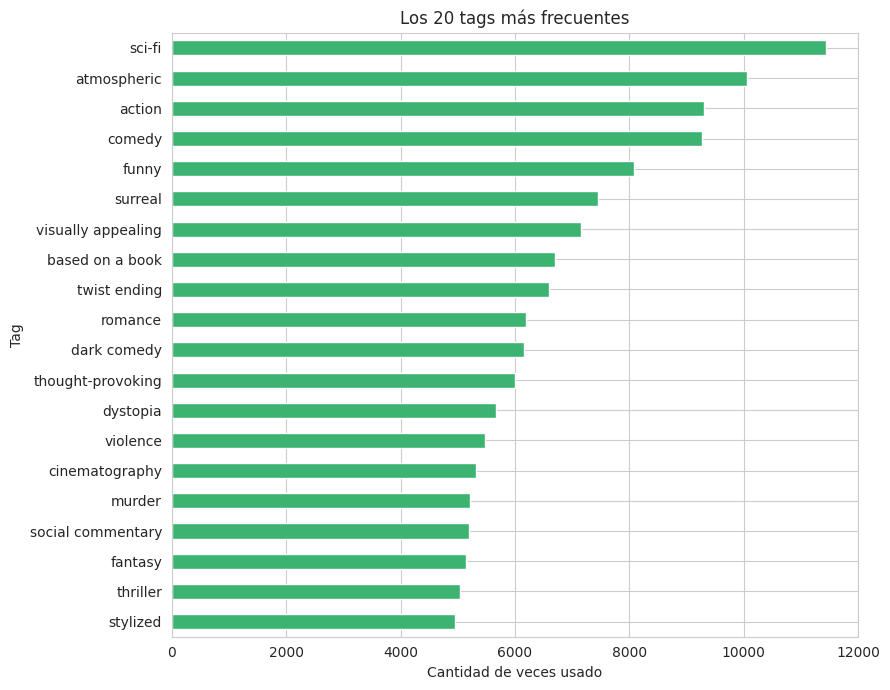

In [10]:
plt.figure(figsize=(9, 7))
top_tags.sort_values().plot(kind='barh', color='mediumseagreen')
plt.xlabel('Cantidad de veces usado')
plt.ylabel('Tag')
plt.title('Los 20 tags más frecuentes')
plt.tight_layout()
plt.show()

**Resultados:** los tags más frecuentes son, en su mayoría, **géneros escritos como palabra
libre** (`sci-fi`, `atmospheric`, `action`, `comedy`, `funny`) más que opiniones o nombres propios;
también aparecen temas recurrentes como `based on a book`, `twist ending`, `dark comedy` y
`thought-provoking`.

**Conclusión:** buena parte del etiquetado libre reproduce información que el género de `movies.csv`
ya captura — es decir, el vocabulario espontáneo de los usuarios coincide bastante con las categorías
oficiales, lo cual es una señal indirecta de que ambas fuentes son razonablemente consistentes entre
sí (una pregunta que solo se puede confirmar formalmente cruzando ambas tablas, en
`movies_tags_ratings.ipynb`).

### 6.4 Riqueza de etiquetado por película

**Qué se calcula:** número de tags distintos (normalizados) por película, sus estadísticas
descriptivas y valores atípicos (regla 1.5×IQR).

**Por qué es relevante:** es una variable numérica derivada, propia de esta tabla: indica qué tan
"comentada" está cada película en términos de diversidad de etiquetas, no solo de cantidad de
eventos.

In [11]:
riqueza_por_pelicula = tags_limpio.groupby('movieId')['tag_norm'].nunique()
riqueza_por_pelicula.describe()

count    51069.000000
mean        20.905148
std         56.000985
min          1.000000
25%          2.000000
50%          5.000000
75%         14.000000
max       1047.000000
Name: tag_norm, dtype: float64

In [12]:
q1, q3 = riqueza_por_pelicula.quantile([0.25, 0.75])
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
outliers = (riqueza_por_pelicula > limite_superior).sum()

print(f"Q1={q1}, Q3={q3}, IQR={iqr}, límite superior={limite_superior}")
print(f"Películas por encima del límite: {outliers} ({outliers/len(riqueza_por_pelicula)*100:.2f}%)")

Q1=2.0, Q3=14.0, IQR=12.0, límite superior=32.0
Películas por encima del límite: 6259 (12.26%)


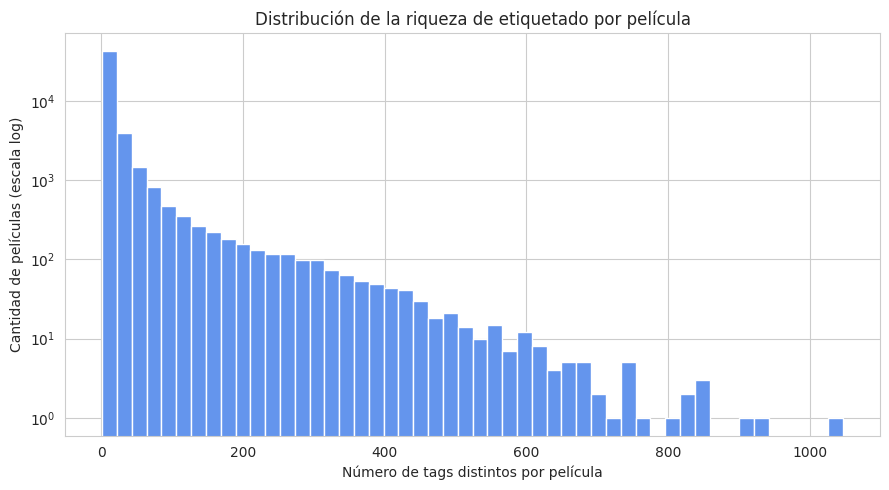

In [13]:
plt.figure(figsize=(9, 5))
riqueza_por_pelicula.plot(kind='hist', bins=50, color='cornflowerblue', log=True)
plt.xlabel('Número de tags distintos por película')
plt.ylabel('Cantidad de películas (escala log)')
plt.title('Distribución de la riqueza de etiquetado por película')
plt.tight_layout()
plt.show()

**Resultados:** en promedio cada película tiene 20.9 tags distintos, pero la mediana es solo 5 —
media muy por encima de la mediana, señal de asimetría hacia la derecha. El máximo es 1,047 tags
distintos para una sola película. Con la regla de 1.5×IQR (límite superior = 32), 6,259 películas
(12.26%) son atípicas en su riqueza de etiquetado.

**Conclusión:** igual que la actividad por usuario en `ratings`, la riqueza de etiquetado tiene una
cola larga: la mayoría de las películas etiquetadas tiene pocos tags distintos (75% tiene 14 o menos),
pero un grupo pequeño de películas muy comentadas concentra una diversidad de vocabulario
desproporcionada. El máximo de 1,047 es un valor extremo que vale la pena investigar en la siguiente
sección.

### 6.5 Actividad de etiquetado por usuario

**Qué se calcula:** número de eventos de etiquetado por usuario, sus estadísticas descriptivas y
el usuario más activo.

**Por qué es relevante:** permite ver si la actividad de etiquetado está repartida entre muchos
usuarios o concentrada en pocos — determinante para interpretar correctamente el resto del
notebook.

In [14]:
eventos_por_usuario = tags_limpio.groupby('userId').size()
print(eventos_por_usuario.describe())
print()
print("Top 5 usuarios más activos etiquetando:")
print(eventos_por_usuario.sort_values(ascending=False).head())

count     15833.000000
mean        125.852965
std        5757.526971
min           1.000000
25%           2.000000
50%           5.000000
75%          25.000000
max      721567.000000
dtype: float64

Top 5 usuarios más activos etiquetando:
userId
78213     721567
68821      20311
119227     20256
147560     18689
159300     16656
dtype: int64


In [15]:
usuario_top = eventos_por_usuario.idxmax()
eventos_top = eventos_por_usuario.max()
proporcion_top = eventos_top / len(tags_limpio) * 100

print(f"Usuario más activo: userId {usuario_top}")
print(f"Eventos de etiquetado de ese usuario: {eventos_top:,} ({proporcion_top:.2f}% del total)")
print(f"Películas distintas que etiquetó: {tags_limpio.loc[tags_limpio['userId'] == usuario_top, 'movieId'].nunique():,}")
print()
print("Muestra de su actividad (nótese la hora exacta):")
print(tags_limpio.loc[tags_limpio['userId'] == usuario_top, ['movieId', 'tag', 'tag_datetime']].head(15))

Usuario más activo: userId 78213
Eventos de etiquetado de ese usuario: 721,567 (36.21% del total)
Películas distintas que etiquetó: 40,144

Muestra de su actividad (nótese la hora exacta):
        movieId                               tag        tag_datetime
595612        1                             1990s 2021-02-04 19:45:42
595613        1                     3 dimensional 2021-02-04 19:45:45
595614        1                                3d 2021-02-04 19:45:45
595615        1                     action figure 2021-02-04 19:45:42
595616        1                         affection 2021-02-04 19:45:44
595617        1                             alien 2021-02-04 19:45:43
595618        1                      animated dog 2021-02-04 19:45:43
595619        1  animated fictional tv commercial 2021-02-04 19:45:43
595620        1                           antenna 2021-02-04 19:45:45
595621        1               anthropomorphic toy 2021-02-04 19:45:43
595622        1                  anthropo

**Resultados:** en promedio cada usuario pone 125.9 etiquetas, pero la mediana es solo 5 — una
asimetría extrema. El usuario `userId` 78213 puso **721,567 etiquetas**, el **36.2% de toda la tabla
`tags`** él solo, sobre 40,144 películas distintas (más del triple de las 32,935 que tienen tags de
cualquier *otro* usuario). Al revisar una muestra de su actividad, se observan decenas de tags
distintos asignados a la *misma* película en el *mismo segundo* (por ejemplo, sobre `movieId` 1 puso
"1990s", "3 dimensional", "3d", "action figure", "affection"... todos a las 19:45 del mismo día), con
vocabulario que se parece más a palabras clave temáticas (keywords estilo IMDb) que a opiniones
espontáneas de una persona viendo una película.

**Conclusión:** esto no tiene el patrón de un usuario humano etiquetando películas que vio — es mucho
más consistente con una **cuenta automatizada** que cargó un conjunto de keywords/metadatos en bloque
para decenas de miles de películas. Es el hallazgo más importante de este notebook: más de un tercio
de la tabla `tags` proviene de una sola fuente no representativa de "opinión de usuario", y explica el
pico de actividad de 2021 visto en la sección 6.2 y el máximo de 1,047 tags distintos en una película
visto en la sección 6.4. Cualquier análisis que trate `tags` como "lo que opinan los usuarios" debería
considerar excluir o tratar aparte a este usuario — se explora el impacto de hacerlo en la siguiente
sección.

### 6.6 Robustez de los resultados al excluir al usuario automatizado

**Qué se calcula:** las mismas estadísticas de las secciones 6.4 y 6.5 (riqueza de etiquetado
por película, eventos por usuario), pero excluyendo al `userId` 78213 identificado como probable
cuenta automatizada.

**Por qué es relevante:** permite dimensionar qué tanto cambia el panorama general una vez que se
quita esa fuente atípica, y da una imagen más representativa del etiquetado hecho por personas.

In [16]:
tags_sin_bot = tags_limpio[tags_limpio['userId'] != usuario_top]

eventos_por_usuario_sb = tags_sin_bot.groupby('userId').size()
riqueza_por_pelicula_sb = tags_sin_bot.groupby('movieId')['tag_norm'].nunique()

print(f"Filas sin el usuario {usuario_top}: {len(tags_sin_bot):,} de {len(tags_limpio):,}")
print(f"Películas con al menos un tag (sin ese usuario): {tags_sin_bot['movieId'].nunique():,}")
print()
print("Eventos por usuario, sin el usuario automatizado:")
print(eventos_por_usuario_sb.describe())
print()
print("Riqueza de etiquetado por película, sin el usuario automatizado:")
print(riqueza_por_pelicula_sb.describe())

Filas sin el usuario 78213: 1,271,063 de 1,992,630
Películas con al menos un tag (sin ese usuario): 32,935

Eventos por usuario, sin el usuario automatizado:
count    15832.000000
mean        80.284424
std        521.571432
min          1.000000
25%          2.000000
50%          5.000000
75%         25.000000
max      20311.000000
dtype: float64

Riqueza de etiquetado por película, sin el usuario automatizado:
count    32935.000000
mean        12.104539
std         21.718609
min          1.000000
25%          2.000000
50%          5.000000
75%         13.000000
max        674.000000
Name: tag_norm, dtype: float64


**Resultados:** sin ese usuario quedan 1,271,063 eventos de etiquetado (63.8% del original) y
32,935 películas con al menos un tag (frente a las 51,069 originales — se pierden 18,134 películas que
*solo* tenían tags de ese usuario). La actividad por usuario sigue siendo asimétrica (mediana sigue en
5, pero el máximo baja de 721,567 a 20,311) y la riqueza de etiquetado por película baja de una media
de 20.9 a 12.1, con un máximo de 674 en vez de 1,047.

**Conclusión:** el usuario automatizado no es la única fuente de asimetría (sigue habiendo cola larga
incluso sin él: hay usuarios humanos con más de 13,000 etiquetas), pero sí infla notablemente las
cifras generales y, sobre todo, es responsable de que 18,134 películas (35.5% de las que tienen algún
tag) tengan *únicamente* etiquetas automatizadas y ninguna opinión humana. Para cualquier análisis
futuro que use `tags` como proxy de "lo que dicen los usuarios" sobre una película (por ejemplo, en
`movies_tags_ratings.ipynb`), conviene tener presente esta distinción, o filtrar explícitamente a este
usuario si el objetivo es capturar etiquetado genuinamente humano.

## 7. Conclusiones y limitaciones

### Conclusiones

1. `tags.csv` tiene 1,992,636 filas prácticamente limpias (solo 6 nulos, sin duplicados), con 15,834
   usuarios y 51,069 películas etiquetadas (58.7% del catálogo).
2. La normalización de texto (minúsculas + espacios) reduce los tags únicos de 140,191 a 131,350 —
   un ajuste necesario aunque no elimina errores de tipeo ni sinónimos.
3. Los tags más frecuentes son mayormente géneros escritos como palabra libre (`sci-fi`,
   `atmospheric`, `action`, `comedy`, `funny`), sugiriendo consistencia con el género oficial de
   `movies.csv`.
4. **Hallazgo principal:** el `userId` 78213 concentra el 36.2% de todos los eventos de etiquetado
   (721,567 de 1,992,630) sobre 40,144 películas, con un patrón (miles de tags por segundo,
   vocabulario tipo keywords) que sugiere una cuenta automatizada y no una persona. Sin este usuario,
   18,134 películas se quedarían sin ningún tag.
5. Tanto la riqueza de etiquetado por película como la actividad por usuario tienen una cola larga muy
   pronunciada, con y sin el usuario automatizado: unas pocas películas/usuarios concentran una
   fracción desproporcionada de la actividad.

### Limitaciones

* La normalización de texto es básica (mayúsculas y espacios); no corrige errores de tipeo ni fusiona
  sinónimos, así que la cantidad real de conceptos únicos distintos es probablemente menor a 131,350.
* El `userId` 78213 fue identificado como probable cuenta automatizada por patrones de comportamiento
  (velocidad, volumen, vocabulario), no por un campo explícito del dataset que confirme su naturaleza;
  es una inferencia razonable pero no una certeza documentada.
* Solo el 58.7% del catálogo de `movies` tiene al menos un tag; cualquier análisis que use `tags` para
  caracterizar películas deja automáticamente fuera al resto del catálogo.
* Este análisis usa únicamente `tags`; no incorpora calificaciones ni el catálogo de películas, por lo
  que no permite decir si el etiquetado se relaciona con qué tan bien calificada está una película —
  ese cruce corresponde a `movies_tags_ratings.ipynb`.